In [1]:
# ============================================================
#  run_blogfeedback_ppci_mean_twofold_cf.py
#
#  BlogFeedback conditional mean demo (Two-fold CF on unlabeled only)
#  (NO RBC, per your request)
#
#  Loop order (same spirit as your latest census_income twofold script):
#    - For each x0:
#        * exclude exact duplicates of x0 from sampling pool
#        * tune ell via pilot-based ell0_hat and local LOGELL grid (LOO-CV)
#        * for r = 1..R:
#            - sample ONE unlabeled set Xu (size N_unlab_total) from pool (disjoint from pilot)
#            - split Xu into two folds and build twofold weights (learned from Xu only)
#            - run B MC reps:
#                + resample labeled set (size n_label) disjoint from (pilot ∪ Xu)
#                + run PPCI / LO / NW / PPI / crossPPI
#        * aggregate metrics over ALL reps (R*B) and print FINAL results
#        * checkpoint-save one row per x0 to CSV
#
#  Data (from blogfeedback_ppci.csv):
#    - X_total: standardized already (columns x*)
#    - Y_total: logy
#    - f_total: logyhat  (black-box predictor output)
#
#  Requires conditional_mean_functions.py provides:
#    select_logell_by_pilot_logo_cv
#    build_twofold_weights
#    ppci_conditional_mean_cf
#    ppci_conditional_mean_label_only_cf
#    nw_point_mean_ci_matern52
# ============================================================

import os
import sys
import csv
import numpy as np
import cupy as cp
import pandas as pd

from ppi_py import ppi_mean_ci, ppi_mean_pointestimate, crossppi_mean_ci

np.set_printoptions(precision=4, suppress=True)

try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

parent_dir = os.path.abspath(os.path.join(current_dir, ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from conditional_mean_functions import (
    select_logell_by_pilot_logo_cv,
    build_twofold_weights,
    ppci_conditional_mean_cf,
    ppci_conditional_mean_label_only_cf,
    nw_point_mean_ci_matern52,
)

# -------------------------
# helper: ddof=1 std from sums
# -------------------------
def std_ddof1_from_sums(sum_x: float, sum_x2: float, n: int) -> float:
    if n <= 1:
        return 0.0
    var = (sum_x2 - (sum_x * sum_x) / n) / (n - 1)
    return float(np.sqrt(max(var, 0.0)))

# -------------------------
# helper: write CSV
# -------------------------
def write_results_to_csv(results_list, csv_path):
    if len(results_list) == 0:
        raise ValueError("results_list is empty; nothing to write.")
    fieldnames = list(results_list[0].keys())
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in results_list:
            writer.writerow(row)
    print(f"\n[Saved Checkpoint] {csv_path}")

# -------------------------
# core: simulate one x0 (twofold CF, aggregate over R*B)
# -------------------------
def simulate_one_x0_blogfeedback_twofold(
    X_total: np.ndarray,
    Y_total: np.ndarray,
    f_total: np.ndarray,           # = Yhat_total
    x0_scaled: np.ndarray,
    seed_base: int,
    R: int,
    B: int,
    n_label: int,
    N_unlab_total: int,
    n_pilot: int,
    lam_grid: np.ndarray,
    LOGELL_grid_size: int,
    c_min: float,
    c_max: float,
    alpha: float,
    z_alpha: float,
    theta0_mode: str = "smooth",
    denom_floor: float = 1e-10,
):
    X_total = np.asarray(X_total, dtype=float)
    Y_total = np.asarray(Y_total, dtype=float)
    f_total = np.asarray(f_total, dtype=float)
    x0_scaled = np.asarray(x0_scaled, dtype=float).ravel()

    n_total = int(Y_total.size)
    total_reps = int(R * B)

    # ---- duplicates of x0 (exclude from sampling pool) ----
    mask_x0 = np.all(X_total == x0_scaled.reshape(1, -1), axis=1)
    n_x0 = int(mask_x0.sum())
    print(f"[x0] exact duplicate observations (excluded from pool): {n_x0}")

    theta0_obs = float(np.mean(Y_total[mask_x0])) if np.any(mask_x0) else np.nan

    # ---- theta0_smooth (NW on FULL pool, oracle ell = median distance) ----
    dists_full = np.linalg.norm(X_total - x0_scaled.reshape(1, -1), axis=1)
    ell_oracle = float(np.median(dists_full))

    X_full_gpu = cp.asarray(X_total)
    Y_full_gpu = cp.asarray(Y_total)
    theta0_s, _, _ = nw_point_mean_ci_matern52(
        X_l=X_full_gpu,
        Y_l=Y_full_gpu,
        x0=cp.asarray(x0_scaled),
        ell=ell_oracle,
        z_alpha=z_alpha,
    )
    theta0_smooth = float(theta0_s)

    if theta0_mode == "obs":
        if np.isnan(theta0_obs):
            raise ValueError("theta0_mode='obs' but x0 has no exact obs.")
        theta0 = theta0_obs
        theta0_source = "obs"
    elif theta0_mode == "smooth":
        theta0 = theta0_smooth
        theta0_source = "smooth"
    elif theta0_mode == "mix":
        if not np.isnan(theta0_obs):
            theta0 = theta0_obs
            theta0_source = "obs"
        else:
            theta0 = theta0_smooth
            theta0_source = "smooth"
    else:
        raise ValueError("theta0_mode must be 'obs'/'smooth'/'mix'.")

    # ---- sampling pool excludes duplicates ----
    idx_pool = np.flatnonzero(~mask_x0)
    N_used = int(idx_pool.size)

    # ---- budget feasibility check ----
    # Need: pilot + Xu + labeled <= N_used
    min_required = n_pilot + N_unlab_total + n_label
    if N_used < min_required:
        raise ValueError(
            f"N_used={N_used} too small for pilot({n_pilot}) + Xu({N_unlab_total}) + labeled({n_label})."
        )

    # ---- choose pilot ONCE for this x0 ----
    rng_pilot = np.random.default_rng(seed_base + 100_000 * int(np.sum(np.abs(x0_scaled)) * 1e6) % 10_000)
    perm_pool = rng_pilot.permutation(idx_pool)
    idx_pilot = perm_pool[:n_pilot]
    idx_after_pilot = perm_pool[n_pilot:]  # remaining for Xu/labeled draws

    # GPU pilot
    X_pilot_gpu = cp.asarray(X_total[idx_pilot])
    Y_pilot_gpu = cp.asarray(Y_total[idx_pilot])
    loo_groups = np.arange(n_pilot, dtype=int)

    # ---- pilot-based ell tuning: ell0_hat -> local LOGELL grid -> LOO-CV ----
    x0_gpu = cp.asarray(x0_scaled)
    d_pilot = cp.linalg.norm(X_pilot_gpu - x0_gpu[None, :], axis=1)
    ell0_hat = float(cp.asnumpy(cp.median(d_pilot)))
    ell0_hat = max(1e-8, ell0_hat)

    ell_low = max(1e-8, c_min * ell0_hat)
    ell_high = c_max * ell0_hat
    LOGELL_grid_local = np.linspace(np.log(ell_low), np.log(ell_high), int(LOGELL_grid_size))

    ell_star, _ = select_logell_by_pilot_logo_cv(
        LOGELL_grid=LOGELL_grid_local,
        X_pilot=X_pilot_gpu,
        Y_pilot=Y_pilot_gpu,
        group_labels=loo_groups,
    )
    ell_star = float(ell_star)

    # --------------------------
    # Accumulators over ALL reps = R*B
    # --------------------------
    # PPCI
    sum_th_ppci = 0.0
    sum_sqerr_ppci = 0.0
    sum_cov_ppci = 0.0
    sum_width_ppci = 0.0
    sum_s2_Ymf = 0.0
    sum_s2_Ymf2 = 0.0
    sum_s2_f = 0.0
    sum_s2_f2 = 0.0

    # LO (label-only)
    sum_th_lo = 0.0
    sum_sqerr_lo = 0.0
    sum_cov_lo = 0.0
    sum_width_lo = 0.0
    sum_s2_Y = 0.0
    sum_s2_Y2 = 0.0

    # NW
    sum_th_nw = 0.0
    sum_sqerr_nw = 0.0
    sum_cov_nw = 0.0
    sum_width_nw = 0.0

    # PPI
    sum_th_ppi = 0.0
    sum_sqerr_ppi = 0.0
    sum_cov_ppi = 0.0
    sum_width_ppi = 0.0

    # crossPPI
    sum_cov_crossppi = 0.0
    sum_width_crossppi = 0.0

    # diagnostics averaged over r
    sum_lam1 = 0.0
    sum_lam2 = 0.0
    sum_den_u = 0.0

    # --------------------------
    # Outer loop over r: fresh Xu each r (NOT shared across x0)
    # --------------------------
    for r in range(1, R + 1):
        rng_r = np.random.default_rng(seed_base + 10_000_000 * r + 1_000 * (int(ell0_hat * 1e6) % 10_000))

        # sample Xu from "after pilot" pool (disjoint from pilot by construction)
        if idx_after_pilot.size < N_unlab_total + n_label:
            raise ValueError(
                f"After pilot, remaining pool size={idx_after_pilot.size} too small for Xu({N_unlab_total}) + labeled({n_label})."
            )

        perm_after = rng_r.permutation(idx_after_pilot)
        idx_u_full = perm_after[:N_unlab_total]
        idx_l_pool = perm_after[N_unlab_total:]  # remaining for labeled draws (disjoint from Xu)

        # build two-fold weights on Xu only
        X_u_gpu = cp.asarray(X_total[idx_u_full])
        N_u = int(N_unlab_total)

        perm_u = rng_r.permutation(N_u)
        half = N_u // 2
        idx_fold1 = perm_u[:half]
        idx_fold2 = perm_u[half:]

        w1_hat, w2_hat, w_oof_u, den_u, lam1, lam2 = build_twofold_weights(
            X_u=X_u_gpu,
            x0=x0_scaled,
            ell=ell_star,
            lam_grid=lam_grid,
            idx_fold1=idx_fold1,
            idx_fold2=idx_fold2,
            make_plot=False,
        )

        sum_lam1 += float(lam1)
        sum_lam2 += float(lam2)
        sum_den_u += float(den_u)

        # cache unlabeled predictor outputs f_u for this r (fixed across b)
        f_u_cpu = f_total[idx_u_full].ravel()
        f_u = cp.asarray(f_u_cpu)

        # labeled RNG stream for this (x0, r)
        rng_inner = np.random.default_rng(seed_base + 1_000_000 * r + 12345)

        if idx_l_pool.size < n_label:
            raise ValueError(
                f"Labeled pool size={idx_l_pool.size} too small for n_label={n_label} (after removing pilot+Xu)."
            )

        for _ in range(B):
            # sample labeled indices (disjoint from pilot and Xu)
            idx_l = rng_inner.choice(idx_l_pool, size=n_label, replace=False)

            X_l = cp.asarray(X_total[idx_l])
            Y_l = cp.asarray(Y_total[idx_l].ravel())
            f_l = cp.asarray(f_total[idx_l].ravel())

            # --- PPCI (twofold CF) ---
            th, se, (lo, up), ex = ppci_conditional_mean_cf(
                X_l=X_l, Y_l=Y_l, f_l=f_l, f_u=f_u,
                w1_hat=w1_hat, w2_hat=w2_hat, w_oof_u=w_oof_u,
                z_alpha=z_alpha, return_extras=True
            )
            th = float(th)
            cov = float(lo <= theta0 <= up)
            width = float(up - lo)

            sum_th_ppci += th
            sum_sqerr_ppci += (th - theta0) ** 2
            sum_cov_ppci += cov
            sum_width_ppci += width

            s2_y_m_f = float(ex["sigma2_Y_minus_f"])
            s2_fv = float(ex["sigma2_f"])
            sum_s2_Ymf += s2_y_m_f
            sum_s2_Ymf2 += s2_y_m_f ** 2
            sum_s2_f += s2_fv
            sum_s2_f2 += s2_fv ** 2

            # --- LO baseline (label-only conditional, but still uses w-hats) ---
            th2, se2, (lo2, up2), ex2 = ppci_conditional_mean_label_only_cf(
                X_l=X_l, Y_l=Y_l,
                w1_hat=w1_hat, w2_hat=w2_hat,
                z_alpha=z_alpha, return_extras=True,
                denom_floor=denom_floor
            )
            th2 = float(th2)
            cov2 = float(lo2 <= theta0 <= up2)
            width2 = float(up2 - lo2)

            sum_th_lo += th2
            sum_sqerr_lo += (th2 - theta0) ** 2
            sum_cov_lo += cov2
            sum_width_lo += width2

            s2y = float(ex2["sigma2_Y"])
            sum_s2_Y += s2y
            sum_s2_Y2 += s2y ** 2

            # --- NW baseline (conditional NW on labeled, using ell_star) ---
            thn, sen, (lon, upn) = nw_point_mean_ci_matern52(
                X_l=X_l, Y_l=Y_l,
                x0=cp.asarray(x0_scaled),
                ell=ell_star,
                z_alpha=z_alpha
            )
            thn = float(thn)
            covn = float(lon <= theta0 <= upn)
            widthn = float(upn - lon)

            sum_th_nw += thn
            sum_sqerr_nw += (thn - theta0) ** 2
            sum_cov_nw += covn
            sum_width_nw += widthn

            # --- PPI / crossPPI (global mean, CPU) ---
            Y_l_cpu = cp.asnumpy(Y_l).ravel()
            f_l_cpu = cp.asnumpy(f_l).ravel()

            ppi_lo, ppi_up = ppi_mean_ci(Y_l_cpu, f_l_cpu, f_u_cpu, alpha=alpha)
            ppi_th = float(ppi_mean_pointestimate(Y_l_cpu, f_l_cpu, f_u_cpu))
            cov3 = float(ppi_lo <= theta0 <= ppi_up)
            width3 = float(ppi_up - ppi_lo)

            sum_th_ppi += ppi_th
            sum_sqerr_ppi += (ppi_th - theta0) ** 2
            sum_cov_ppi += cov3
            sum_width_ppi += width3

            f_l_2d = f_l_cpu.reshape(-1, 1)
            f_u_2d = f_u_cpu.reshape(-1, 1)
            cross_lo, cross_up = crossppi_mean_ci(Y_l_cpu, f_l_2d, f_u_2d, alpha=alpha)
            sum_cov_crossppi += float(cross_lo <= theta0 <= cross_up)
            sum_width_crossppi += float(cross_up - cross_lo)

    # --------------------------
    # Final aggregation over ALL reps = R*B
    # --------------------------
    PPCI_theta_mean = sum_th_ppci / total_reps
    PPCI_theta_rmse = float(np.sqrt(sum_sqerr_ppci / total_reps))
    PPCI_coverage = sum_cov_ppci / total_reps
    PPCI_avg_ci_width = sum_width_ppci / total_reps

    PPCI_sigma2_Y_minus_f_mean = sum_s2_Ymf / total_reps
    PPCI_sigma2_f_mean = sum_s2_f / total_reps
    PPCI_sigma2_Y_minus_f_std = std_ddof1_from_sums(sum_s2_Ymf, sum_s2_Ymf2, total_reps)
    PPCI_sigma2_f_std = std_ddof1_from_sums(sum_s2_f, sum_s2_f2, total_reps)

    LO_theta_mean = sum_th_lo / total_reps
    LO_theta_rmse = float(np.sqrt(sum_sqerr_lo / total_reps))
    LO_coverage = sum_cov_lo / total_reps
    LO_avg_ci_width = sum_width_lo / total_reps
    LO_sigma2_Y_mean = sum_s2_Y / total_reps
    LO_sigma2_Y_std = std_ddof1_from_sums(sum_s2_Y, sum_s2_Y2, total_reps)

    NW_theta_mean = sum_th_nw / total_reps
    NW_theta_rmse = float(np.sqrt(sum_sqerr_nw / total_reps))
    NW_coverage = sum_cov_nw / total_reps
    NW_avg_ci_width = sum_width_nw / total_reps

    PPI_theta_mean = sum_th_ppi / total_reps
    PPI_theta_rmse = float(np.sqrt(sum_sqerr_ppi / total_reps))
    PPI_coverage = sum_cov_ppi / total_reps
    PPI_avg_ci_width = sum_width_ppi / total_reps

    crossPPI_coverage = sum_cov_crossppi / total_reps
    crossPPI_avg_ci_width = sum_width_crossppi / total_reps

    # diagnostics averaged over r
    lambda_1_mean = sum_lam1 / R
    lambda_2_mean = sum_lam2 / R
    den_u_mean = sum_den_u / R
    lambda_hat = 0.5 * (lambda_1_mean + lambda_2_mean)

    out = {
        # x0 / truth
        "x0_index": -1,  # 外层填
        "x0_vec": np.array(x0_scaled, dtype=float).tolist(),
        "theta0_mode": theta0_mode,
        "theta0_source": theta0_source,
        "theta0": float(theta0),
        "theta0_obs": float(theta0_obs) if not np.isnan(theta0_obs) else np.nan,
        "theta0_smooth": float(theta0_smooth),
        "ell_oracle": float(ell_oracle),

        # tuning
        "c_min": float(c_min),
        "c_max": float(c_max),
        "ell0_hat": float(ell0_hat),
        "ell_low": float(ell_low),
        "ell_high": float(ell_high),
        "ell_star": float(ell_star),

        # lambda diagnostics (means over r)
        "lambda_hat": float(lambda_hat),
        "lambda_1": float(lambda_1_mean),
        "lambda_2": float(lambda_2_mean),
        "den_u": float(den_u_mean),

        # budgets
        "R": int(R),
        "B": int(total_reps),          # aggregated over R*B
        "B_per_r": int(B),
        "n_label": int(n_label),
        "n_pilot": int(n_pilot),
        "N_unlab_total": int(N_unlab_total),

        # PPCI
        "PPCI_theta_mean": float(PPCI_theta_mean),
        "PPCI_theta_rmse": float(PPCI_theta_rmse),
        "PPCI_coverage": float(PPCI_coverage),
        "PPCI_avg_ci_width": float(PPCI_avg_ci_width),
        "PPCI_sigma2_Y_minus_f_mean": float(PPCI_sigma2_Y_minus_f_mean),
        "PPCI_sigma2_f_mean": float(PPCI_sigma2_f_mean),
        "PPCI_sigma2_Y_minus_f_std": float(PPCI_sigma2_Y_minus_f_std),
        "PPCI_sigma2_f_std": float(PPCI_sigma2_f_std),

        # legacy alias (keep your old schema naming)
        "PPCI_sigma2_Y_minus_A_mean": float(PPCI_sigma2_Y_minus_f_mean),
        "PPCI_sigma2_A_mean": float(PPCI_sigma2_f_mean),
        "PPCI_sigma2_Y_minus_A_std": float(PPCI_sigma2_Y_minus_f_std),
        "PPCI_sigma2_A_std": float(PPCI_sigma2_f_std),

        # LO
        "LO_theta_mean": float(LO_theta_mean),
        "LO_theta_rmse": float(LO_theta_rmse),
        "LO_coverage": float(LO_coverage),
        "LO_avg_ci_width": float(LO_avg_ci_width),
        "LO_sigma2_Y_mean": float(LO_sigma2_Y_mean),
        "LO_sigma2_Y_std": float(LO_sigma2_Y_std),

        # NW
        "NW_theta_mean": float(NW_theta_mean),
        "NW_theta_rmse": float(NW_theta_rmse),
        "NW_coverage": float(NW_coverage),
        "NW_avg_ci_width": float(NW_avg_ci_width),

        # PPI
        "PPI_theta_mean": float(PPI_theta_mean),
        "PPI_theta_rmse": float(PPI_theta_rmse),
        "PPI_coverage": float(PPI_coverage),
        "PPI_avg_ci_width": float(PPI_avg_ci_width),

        # crossPPI
        "crossPPI_coverage": float(crossPPI_coverage),
        "crossPPI_avg_ci_width": float(crossPPI_avg_ci_width),
    }
    return out


# ============================================================
# entry point
# ============================================================
if __name__ == "__main__":
    # choose GPU
    GPU_ID = 2
    cp.cuda.Device(GPU_ID).use()

    # --------------------------------------------------------
    # 1) Load BlogFeedback PPCI data
    # --------------------------------------------------------
    ppci_csv = "./blogfeedback_ppci.csv"
    x0_csv = "./blogfeedback_ppci_x0.csv"

    df_ppci = pd.read_csv(ppci_csv)
    df_x0 = pd.read_csv(x0_csv)

    x_cols = [c for c in df_ppci.columns if c.startswith("x")]
    X_total = df_ppci[x_cols].to_numpy(dtype=np.float32)
    Y_total = df_ppci["logy"].to_numpy(dtype=np.float32)
    f_total = df_ppci["logyhat"].to_numpy(dtype=np.float32)

    n_total, d = X_total.shape
    print(f"Loaded BlogFeedback PPCI data: n_total={n_total}, d={d}")

    x0_list = [row.to_numpy(dtype=np.float32) for _, row in df_x0[x_cols].iterrows()]
    print(f"Loaded {len(x0_list)} x0 points from {x0_csv}")

    # --------------------------------------------------------
    # 2) Hyperparams (twofold CF version)
    # --------------------------------------------------------
    seed_base = 2025

    R = 5
    B = 200                  # total reps per x0 = R*B
    n_label = 300

    N_unlab_total = 10000    # Xu size per r
    n_pilot = 300

    alpha = 0.05
    z_alpha = 1.96

    # lambda grid: O(1/n_label)
    lam_grid = np.logspace(np.log10(0.05 / n_label), np.log10(10.0 / n_label), 80)

    # local ell grid around ell0_hat
    LOGELL_grid_size = 50
    c_min = 0.925
    c_max = 1.075

    # --------------------------------------------------------
    # 3) Loop x0 and run (checkpoint each x0)
    # --------------------------------------------------------
    save_dir = os.path.join(current_dir, "results")
    os.makedirs(save_dir, exist_ok=True)
    csv_path = os.path.join(save_dir, "blogfeedback_ppci_mean_twofold_cf_checkpoint.csv")

    all_rows = []

    total_reps = int(R * B)

    for k, x0 in enumerate(x0_list, 1):
        print("\n" + "-" * 90)
        print(f"[x0 #{k}/{len(x0_list)}] running... (aggregate R*B={total_reps})")

        out = simulate_one_x0_blogfeedback_twofold(
            X_total=X_total,
            Y_total=Y_total,
            f_total=f_total,
            x0_scaled=x0,
            seed_base=seed_base + 10_000 * k,
            R=R,
            B=B,
            n_label=n_label,
            N_unlab_total=N_unlab_total,
            n_pilot=n_pilot,
            lam_grid=lam_grid,
            LOGELL_grid_size=LOGELL_grid_size,
            c_min=c_min,
            c_max=c_max,
            alpha=alpha,
            z_alpha=z_alpha,
            theta0_mode="smooth",
            denom_floor=1e-10,
        )
        out["x0_index"] = int(k - 1)
        all_rows.append(out)

        # ---- print (income-style) ----
        print(
            f"theta0={out['theta0']:.6f}  "
            f"theta0_source={out['theta0_source']}  "
            f"ell_oracle={out['ell_oracle']:.4f}  "
            f"ell0_hat={out['ell0_hat']:.4f}  "
            f"c=[{out['c_min']:.2f},{out['c_max']:.2f}]  "
            f"ell_star={out['ell_star']:.4f}  "
            f"lambda_1(mean)={out['lambda_1']:.6g}  lambda_2(mean)={out['lambda_2']:.6g}  "
            f"den_u(mean)={out['den_u']:.4f}"
        )
        print(
            "PPCI (final over R*B): "
            f"rmse={out['PPCI_theta_rmse']:.6f}  "
            f"cov={out['PPCI_coverage']:.3f}  width={out['PPCI_avg_ci_width']:.6f}  "
            f"s2_Ymf={out['PPCI_sigma2_Y_minus_f_mean']:.6g}  "
            f"s2_f={out['PPCI_sigma2_f_mean']:.6g}"
        )
        print(
            "LO   (final over R*B): "
            f"rmse={out['LO_theta_rmse']:.6f}  "
            f"cov={out['LO_coverage']:.3f}  width={out['LO_avg_ci_width']:.6f}  "
            f"s2_Y={out['LO_sigma2_Y_mean']:.6g}"
        )
        print(
            "NW   (final over R*B): "
            f"rmse={out['NW_theta_rmse']:.6f}  "
            f"cov={out['NW_coverage']:.3f}  width={out['NW_avg_ci_width']:.6f}"
        )
        print(
            "PPI  (final over R*B): "
            f"rmse={out['PPI_theta_rmse']:.6f}  "
            f"cov={out['PPI_coverage']:.3f}  width={out['PPI_avg_ci_width']:.6f}"
        )
        print(
            "cPPI (final over R*B): "
            f"cov={out['crossPPI_coverage']:.3f}  width={out['crossPPI_avg_ci_width']:.6f}"
        )

        # checkpoint save
        write_results_to_csv(all_rows, csv_path)

    print("\nDone. All x0 processed and safely saved!")
    print(f"CSV: {csv_path}")

/home/ysui8/yangsuienv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded BlogFeedback PPCI data: n_total=14517, d=280
Loaded 50 x0 points from ./blogfeedback_ppci_x0.csv

------------------------------------------------------------------------------------------
[x0 #1/50] running... (aggregate R*B=1000)
[x0] exact duplicate observations (excluded from pool): 0
theta0=0.514891  theta0_source=smooth  ell_oracle=17.0527  ell0_hat=16.5149  c=[0.93,1.07]  ell_star=15.2763  lambda_1(mean)=0.00411782  lambda_2(mean)=0.00411782  den_u(mean)=0.4188
PPCI (final over R*B): rmse=0.035872  cov=0.947  width=0.141815  s2_Ymf=0.0667215  s2_f=0.0932963
LO   (final over R*B): rmse=0.056840  cov=0.917  width=0.212544  s2_Y=0.156622
NW   (final over R*B): rmse=0.057057  cov=0.911  width=0.211811
PPI  (final over R*B): rmse=0.115482  cov=0.183  width=0.155006
cPPI (final over R*B): cov=0.921  width=0.332697

[Saved Checkpoint] /home/ysui8/yangsuienv/PPCI/blogfeedback_data/results/blogfeedback_ppci_mean_twofold_cf_checkpoint.csv

------------------------------------------

✅ Font 'Helvetica' loaded successfully.
✅ Figure saved as: blogfeedback_mean_x0_rmse_coverage_width.pdf


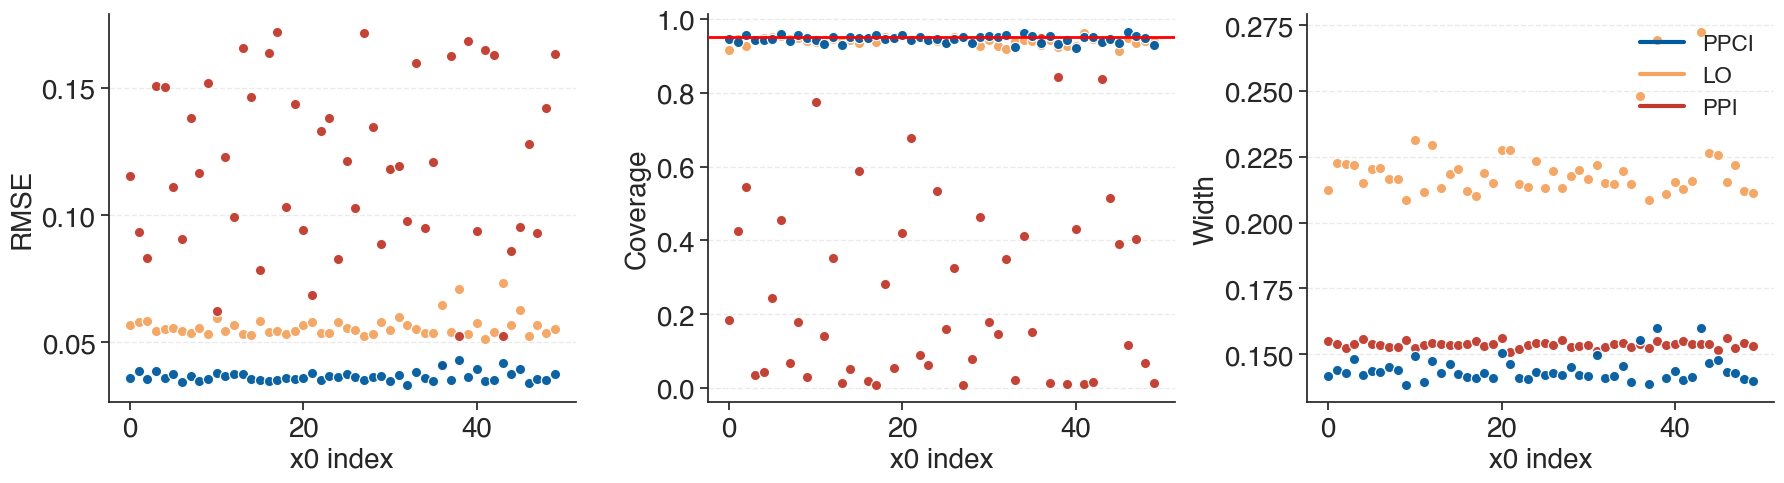

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import os
import numpy as np
from matplotlib.lines import Line2D

# ==========================================
# 0. Font & plotting style configuration (force Helvetica)
# ==========================================
FONT_SIZE = 20
font_path = "/home/ysui8/yangsuienv/Helvetica.ttf"
custom_font_name = "Helvetica"

if os.path.exists(font_path):
    try:
        fm.fontManager.addfont(font_path)
        prop = fm.FontProperties(fname=font_path)
        if prop.get_name() != "Helvetica":
            raise ValueError("Loaded font name mismatch")
        print("✅ Font 'Helvetica' loaded successfully.")
    except Exception as e:
        raise FileNotFoundError(
            f"❌ Unable to load Helvetica font file '{font_path}'. Please ensure the path is correct and the file is valid."
        )
else:
    raise FileNotFoundError(f"❌ Helvetica font file '{font_path}' not found. Please check the path.")

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = [custom_font_name]
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["mathtext.fontset"] = "custom"
mpl.rcParams["mathtext.rm"] = custom_font_name
mpl.rcParams["mathtext.it"] = f"{custom_font_name}:italic"
mpl.rcParams["mathtext.bf"] = f"{custom_font_name}:bold"

sns.set_theme(
    style="ticks",
    rc={
        "axes.grid": False,
        "font.sans-serif": [custom_font_name],
    },
)

# ==========================================
# 1. Read data: BlogFeedback twofold CF results CSV (NEW)
# ==========================================
filename = "./results/blogfeedback_ppci_mean_twofold_cf_checkpoint.csv"
df = pd.read_csv(filename)

required_cols = [
    "x0_index",
    "PPCI_theta_rmse", "PPCI_coverage", "PPCI_avg_ci_width",
    "LO_theta_rmse",   "LO_coverage",   "LO_avg_ci_width",
    "PPI_theta_rmse",  "PPI_coverage",  "PPI_avg_ci_width",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"❌ CSV is missing these columns: {missing}")

df["x0_index"] = df["x0_index"].astype(int)

# ==========================================
# 2. Convert to long format: Method × Metric
# ==========================================
plot_data = []
for _, row in df.iterrows():
    x0i = int(row["x0_index"])

    # PPCI
    plot_data += [
        {"X0": x0i, "Method": "PPCI", "Metric": "RMSE",     "Value": float(row["PPCI_theta_rmse"])},
        {"X0": x0i, "Method": "PPCI", "Metric": "Coverage", "Value": float(row["PPCI_coverage"])},
        {"X0": x0i, "Method": "PPCI", "Metric": "Width",    "Value": float(row["PPCI_avg_ci_width"])},
    ]
    # LO
    plot_data += [
        {"X0": x0i, "Method": "LO", "Metric": "RMSE",     "Value": float(row["LO_theta_rmse"])},
        {"X0": x0i, "Method": "LO", "Metric": "Coverage", "Value": float(row["LO_coverage"])},
        {"X0": x0i, "Method": "LO", "Metric": "Width",    "Value": float(row["LO_avg_ci_width"])},
    ]
    # PPI
    plot_data += [
        {"X0": x0i, "Method": "PPI", "Metric": "RMSE",     "Value": float(row["PPI_theta_rmse"])},
        {"X0": x0i, "Method": "PPI", "Metric": "Coverage", "Value": float(row["PPI_coverage"])},
        {"X0": x0i, "Method": "PPI", "Metric": "Width",    "Value": float(row["PPI_avg_ci_width"])},
    ]

df_long = pd.DataFrame(plot_data)

# ==========================================
# 3. Colors & plotting order
#   draw LO first, then PPI, then PPCI (PPCI on top)
# ==========================================
palette = {
    "PPCI": "#005a9e",
    "LO":   "#f4a460",
    "PPI":  "#c0392b",
}

methods_plot = ["LO", "PPI", "PPCI"]
methods_legend = ["PPCI", "LO", "PPI"]
zorder_scatter = {"LO": 4, "PPI": 5, "PPCI": 6}

metrics = ["RMSE", "Coverage", "Width"]

# ==========================================
# 4. 1×3 panels: RMSE / Coverage / Width
#   scatter only, no connecting lines
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False, sharey=False)

for c, metric in enumerate(metrics):
    ax = axes[c]
    sub_metric = df_long[df_long["Metric"] == metric]

    for method in methods_plot:
        sub = sub_metric[sub_metric["Method"] == method].copy()
        if sub.empty:
            continue

        sub = sub.sort_values("X0")
        x = sub["X0"].values
        y = sub["Value"].values

        ax.scatter(
            x, y,
            color=palette[method],
            marker="o",
            s=55,
            alpha=0.95,
            edgecolors="white",
            linewidths=0.9,
            zorder=zorder_scatter[method],
        )

    if metric == "Coverage":
        ax.axhline(0.95, color="red", linestyle="-", linewidth=2, zorder=10)

    ax.set_ylabel(metric, fontsize=FONT_SIZE)
    ax.set_xlabel("x0 index", fontsize=FONT_SIZE)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname(custom_font_name)

# ==========================================
# 5. Axis styling: keep only left/bottom spines + horizontal dashed gridlines
# ==========================================
for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

    ax.set_axisbelow(True)
    ax.grid(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.xaxis.grid(False)

# ==========================================
# 6. Legend (third panel, upper right)
# ==========================================
method_handles = [
    Line2D([0], [0], color=palette[m], linewidth=3, label=m)
    for m in methods_legend
]
axes[2].legend(handles=method_handles, loc="upper right", fontsize=FONT_SIZE - 4, frameon=False)

plt.tight_layout()
output_file = "blogfeedback_mean_x0_rmse_coverage_width.pdf"
plt.savefig(output_file, bbox_inches="tight", dpi=400)
print(f"✅ Figure saved as: {output_file}")
plt.show()